In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import math

import numpy as np
import cv2
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score
from sklearn.linear_model import LinearRegression
from skimage.morphology import disk, opening, closing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.svm import LinearSVC
from sklearn import metrics
from pathlib import Path
from tqdm import tqdm
import glob


from toolbox_34759.clustering import plot_elbow_graph
from toolbox_34759.camera_model import PinholeCameraModel, CameraMatrix
from toolbox_34759.coordinates import EuclideanPoint, HomogeneousPoint
from toolbox_34759.visual_odometry import StereoVisualOdometry

In [3]:
DATA_PATH = Path('data')

# Q9

In [4]:
# img = cv2.imread(DATA_PATH / 'books.png', cv2.IMREAD_GRAYSCALE) # Didn't provide an available answer
img = cv2.imread(DATA_PATH / 'books.png')
img = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
cedges = cv2.Canny(img, 100, 200)
lines = cv2.HoughLines(cedges, rho=1, theta=0.0017, threshold=200)

lines.shape[0]

32

# Q10

In [5]:
img = cv2.imread(DATA_PATH / 'books.png')
img = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
corners = cv2.cornerHarris(img, blockSize=2, ksize=3, k=0.04)

(corners > 0.01).sum()

np.int64(188)

# Q11

In [6]:
img1 = cv2.imread(DATA_PATH / 'things1.png')
img2 = cv2.imread(DATA_PATH / 'things2.png')
gray1 = cv2.cvtColor(img1, cv2.COLOR_BGR2GRAY)
gray2 = cv2.cvtColor(img2, cv2.COLOR_BGR2GRAY)

features1 = cv2.goodFeaturesToTrack(gray1, maxCorners=100, qualityLevel=0.3, minDistance=7)
features2, status, error = cv2.calcOpticalFlowPyrLK(gray1, gray2, features1, None)

max_x_dist = 0
for i in range(len(features1)):
    if status[i] != 1:
        continue
    
    f1_x = features1[i][0][0]
    f2_x = features2[i][0][0]

    dist = abs(f2_x - f1_x)
    if dist > max_x_dist:
        max_x_dist = dist

max_x_dist


np.float32(15.636841)

# Q12

In [7]:
from toolbox_34759.similarity import sum_of_absolute_differences

measures = np.array([47, 211, 38, 53, 204, 116, 152, 249, 143, 177])
temp = np.array([39, 55, 207])
temp_size = len(temp)

best_match = 3
min_diff = float('inf')
for i in range(temp_size, len(measures)):
    win = measures[i-temp_size:i]
    val = sum_of_absolute_differences(temp, win)
    if val < min_diff:
        best_match = i
        min_diff = val
    
measures[best_match-temp_size:best_match], min_diff

(array([ 38,  53, 204]), np.int64(6))

# Q18

In [8]:
left = cv2.imread(DATA_PATH / 'left.png', cv2.IMREAD_GRAYSCALE)
right = cv2.imread(DATA_PATH / 'right.png', cv2.IMREAD_GRAYSCALE)

sift = cv2.SIFT.create()
kp_l, des_l = sift.detectAndCompute(left, None)
kp_r, des_r = sift.detectAndCompute(right, None)

bf = cv2.BFMatcher()
matches = bf.match(des_l, des_r)
matches = sorted(matches, key=lambda x: x.distance)

n_matches = 2000
pts_l = np.zeros((n_matches, 2), dtype=np.int32)
pts_r = np.zeros((n_matches, 2), dtype=np.int32)
for i, m in enumerate(matches[:n_matches]):
    pts_l[i] = kp_l[m.queryIdx].pt
    pts_r[i] = kp_r[m.trainIdx].pt

F, mask = cv2.findFundamentalMat(pts_l, pts_r, cv2.FM_RANSAC)

pts_l = pts_l[mask.ravel() == 1]
pts_r = pts_r[mask.ravel() == 1]

lines_l = cv2.computeCorrespondEpilines(pts_r.reshape(-1,1,2), 2, F).reshape(-1,3)
lines_r = cv2.computeCorrespondEpilines(pts_l.reshape(-1,1,2), 2, F).reshape(-1,3)

lines_l.mean(axis=0), lines_r.mean(axis=0)


(array([-6.69333264e-02,  9.97691572e-01, -1.26727486e+02], dtype=float32),
 array([-6.7206867e-02,  9.9767345e-01, -1.2466043e+02], dtype=float32))

# Q19

In [9]:
p = 0.98
w = 0.75
np.log(1-p)/np.log(1-w**2)

np.float64(4.732217735314645)

# Q23

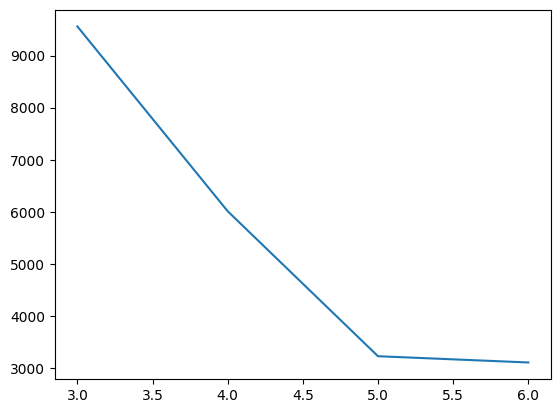

In [10]:
data = np.loadtxt(DATA_PATH / 'clusters.txt')

plot_elbow_graph(data, min_clusters=3, max_clusters=6)

In [11]:
pca = PCA(0.95)
pca.fit(data)

pca.n_components_

np.int64(6)

In [12]:
km = KMeans(n_clusters=5)
km.fit(pca.transform(data))

km.inertia_

2192.1183846510967

# Q24

In [13]:
x = np.loadtxt(DATA_PATH / 'lr_x.txt').reshape(-1,1)
y = np.loadtxt(DATA_PATH / 'lr_y.txt')

lr = LinearRegression()
lr.fit(x, y)

print(f"a = {lr.coef_[0]:.2f}, b={lr.intercept_:.2f}")

a = 0.55, b=19.86


# Q27

In [14]:
x = np.array([3,0.5,2,0.33])
P = np.array([
    [5,1,0,0],
    [1,2,0,0],
    [0,0,5,1],
    [0,0,1,2],
])
dt = 1

F = np.array([
    [1,1/dt,0,0],
    [0,1,0,0],
    [0,0,1,1/dt],
    [0,0,0,1]
])

x_next = F @ x
P_next = F @ P @ F.T

x_next, P_next

(array([3.5 , 0.5 , 2.33, 0.33]),
 array([[9., 3., 0., 0.],
        [3., 2., 0., 0.],
        [0., 0., 9., 3.],
        [0., 0., 3., 2.]]))

# 28

In [15]:
x = np.array([5, 0.5, 7, 0.8])
P = np.array([
    [0.2, 0, 0, 0],
    [0.2, 0.1, 0, 0],
    [0, 0, 0.2, 0],
    [0, 0, 0.2, 0.1],
])

z = np.array([4.8, 7.1])
R = np.ones((2,2))*0.2

H = np.array([
    [1,0,0,0],
    [0,0,1,0]
])

y = z - H @ x
S = H @ P @ H.T + R
K = P @ H.T @ np.linalg.pinv(S)
x_next = x + K @ y

x_next

array([4.83333333, 0.33333333, 7.13333333, 0.93333333])

# 29

In [16]:
from sklearn import svm
x = np.loadtxt(DATA_PATH / 'svm_x.txt', dtype=float)
y = np.loadtxt(DATA_PATH / 'svm_y.txt', dtype=int)

X_train, X_test, y_train, y_test = train_test_split(x, y, test_size=0.3, random_state=1337)

clf = svm.SVC(kernel='linear')
clf.fit(X_train, y_train)

y_pred = clf.predict(X_test)

print("Accuracy:", metrics.accuracy_score(y_test, y_pred))


Accuracy: 0.9590643274853801


# Q32

In [17]:
image_path = DATA_PATH / 'images' # Downloaded from: https://www.dropbox.com/s/jfngvtrydedn7bk/images.zip?dl=1
vo = StereoVisualOdometry(image_path)
vo.run()

Found 51 images.


  2%|▏         | 1/51 [00:00<00:08,  6.24it/s]

100%|██████████| 51/51 [00:14<00:00,  3.60it/s]


In [19]:
vo.get_pose()

(array([[-17.05016773],
        [  0.71755747],
        [ 11.8365131 ]]),
 array([-0.01201903, -1.59592622, -0.07796494]))